In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

In [2]:
# 1st-order linear system
K = 2.0
tau = 5.0

sys = ct.TransferFunction([K], [tau, 1])

t, y = ct.step_response(sys)

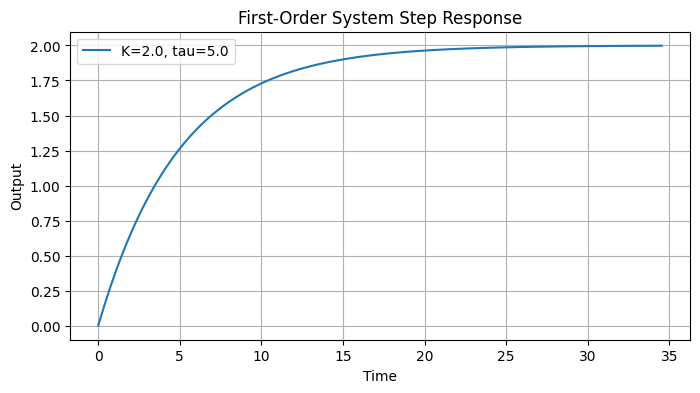

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f"K={K}, tau={tau}")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("First-Order System Step Response")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
# 1st-order linear system with P controller
K = 2.0
Kp = 1.0
tau = 5.0

C = ct.TransferFunction([Kp], [1]) # P controller
sys = ct.TransferFunction([K], [tau, 1]) # unity feedback

closed_sys = ct.feedback(C * sys, 1)

t, y = ct.step_response(closed_sys)

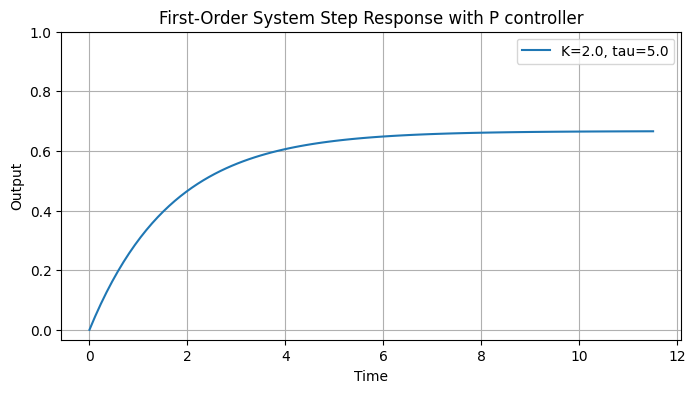

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f"K={K}, tau={tau}")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("First-Order System Step Response with P controller")
plt.ylim(top = 1.0)
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# 1st-order linear system with P & I controller
K = 2.0
Kp = 1.0
Ki = 0.5

tau = 5.0

G = ct.TransferFunction([K], [tau, 1])
C = ct.TransferFunction([Kp, Ki], [1, 0]) # P controller

closed_sys = ct.feedback(C * G, 1)

t, y = ct.step_response(closed_sys)

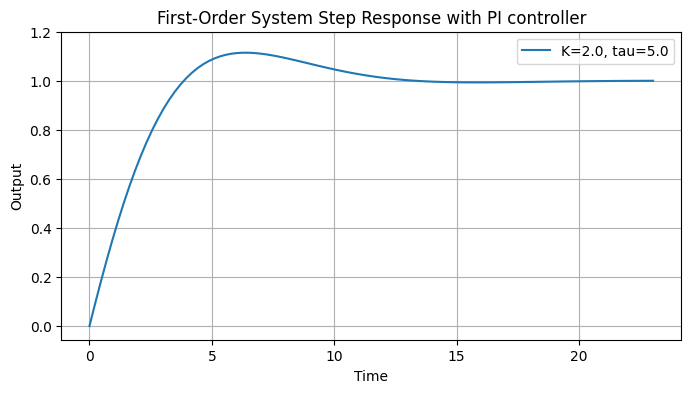

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f"K={K}, tau={tau}")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("First-Order System Step Response with PI controller")
plt.ylim(top = 1.2)
plt.grid(True)
plt.legend()
plt.show()

PID

In [8]:
# =========================
# 1. Plant: first-order system
# G(s) = K / (tau*s + 1)
# =========================
K = 2.0
tau = 5.0
G = ct.TransferFunction([K], [tau, 1])

In [9]:
# =========================
# 2. PID controller
# C(s) = Kp + Ki/s + Kd*s
#      = (Kd*s^2 + Kp*s + Ki) / s
# =========================
Kp = 1.0
Ki = 0.5
Kd = 0.2
C = ct.TransferFunction([Kd, Kp, Ki], [1, 0])

In [10]:
# =========================
# 3. Closed-loop system
# Y/R = C*G / (1 + C*G)
# =========================
closed_sys = ct.feedback(C * G, 1)

In [11]:
# =========================
# 4. Step response
# =========================
t, y = ct.step_response(closed_sys)

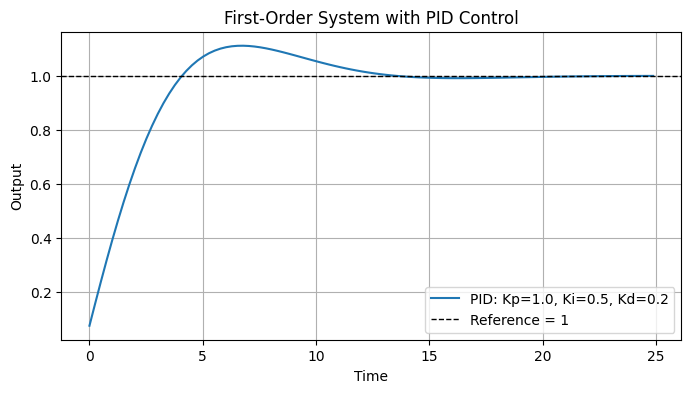

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f'PID: Kp={Kp}, Ki={Ki}, Kd={Kd}')
plt.axhline(1.0, color = 'k', linestyle='--', linewidth=1, label='Reference = 1')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('First-Order System with PID Control')
plt.grid(True)
plt.legend()
plt.show()

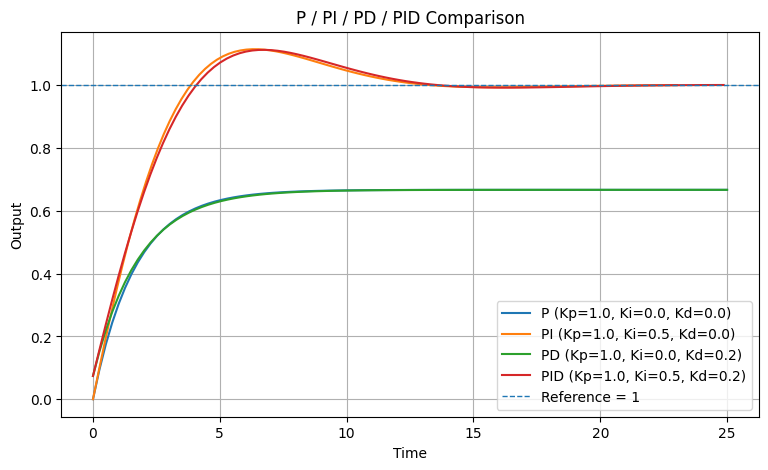

In [13]:
K = 2.0
tau = 5.0
G = ct.TransferFunction([K], [tau, 1])

cases = {
    "P":   (1.0, 0.0, 0.0),
    "PI":  (1.0, 0.5, 0.0),
    "PD":  (1.0, 0.0, 0.2),
    "PID": (1.0, 0.5, 0.2),
}

plt.figure(figsize=(9, 5))

for name, (Kp, Ki, Kd) in cases.items():
    C = ct.TransferFunction([Kd, Kp, Ki], [1, 0])
    closed_sys = ct.feedback(C * G, 1)
    T, y = ct.step_response(closed_sys)
    plt.plot(T, y, label=f'{name} (Kp={Kp}, Ki={Ki}, Kd={Kd})')

plt.axhline(1.0, linestyle='--', linewidth=1, label='Reference = 1')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('P / PI / PD / PID Comparison')
plt.grid(True)
plt.legend()
plt.show()